<a href="https://colab.research.google.com/github/Fadil-blink/240441100072_MohFadil_Tugas2_DeepLearningA/blob/main/tugas_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Deep Learning — CNN vs Residual CNN pada CIFAR-10

- **B.1** — Dataset & Setup: CIFAR-10, PyTorch
- **B.2** — Implementasi Model: Model A (CNN custom) & Model B (mini ResNet dengan residual connection)
- **B.3** — Eksperimen & Evaluasi: kurva loss/accuracy, akurasi test, jumlah parameter, waktu training, confusion matrix

**PENTING:** Sebelum run, aktifkan GPU dulu di Colab:
`Runtime` → `Change runtime type` → `Hardware accelerator` → pilih `T4 GPU` → `Save`.

## 0. Konfigurasi & Import

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Hyperparameter (SAMA untuk kedua model agar perbandingan adil)
SEED = 42
BATCH_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 1e-3
OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {DEVICE}")
if DEVICE.type != "cuda":
    print("⚠️  GPU belum aktif! Aktifkan lewat Runtime > Change runtime type > GPU")

Menggunakan device: cuda


## B.1 — Dataset dan Setup (CIFAR-10)

In [2]:
CIFAR10_CLASSES = ['plane', 'car', 'bird', 'cat', 'deer',
                    'dog', 'frog', 'horse', 'ship', 'truck']

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=test_transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Jumlah data training : {len(trainset)}")
print(f"Jumlah data testing  : {len(testset)}")

100%|██████████| 170M/170M [40:53<00:00, 69.5kB/s]


Jumlah data training : 50000
Jumlah data testing  : 10000


## B.2.j — Model A: CNN Sederhana (Custom)
3 blok Conv-ReLU-Pooling + Fully Connected + output

In [3]:
class ModelA_SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Blok 1: 32x32 -> 16x16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Blok 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Blok 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
            # softmax tidak eksplisit; CrossEntropyLoss sudah menerapkan log-softmax
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## B.2.k — Model B: Mini ResNet (Residual Connection)

In [4]:
class ResidualBlock(nn.Module):
    """Blok residual: Conv-BN-ReLU-Conv-BN + skip connection."""
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity  # <-- residual connection
        out = self.relu(out)
        return out


class ModelB_MiniResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.stage1 = ResidualBlock(32, 32, stride=1)    # 32x32
        self.stage2 = ResidualBlock(32, 64, stride=2)     # 16x16
        self.stage3 = ResidualBlock(64, 128, stride=2)    # 8x8
        self.stage4 = ResidualBlock(128, 128, stride=2)   # 4x4

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Fungsi Training & Evaluasi

In [5]:
def train_model(model, model_name, trainloader, testloader, epochs, lr, device):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        val_loss, val_acc = evaluate(model, testloader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} "
              f"- train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    total_time = time.time() - start_time
    print(f"[{model_name}] Total waktu training: {total_time:.2f} detik "
          f"({total_time/60:.2f} menit)")

    return history, total_time


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


def get_predictions(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def plot_curves(history_a, history_b, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, len(history_a["train_loss"]) + 1)

    axes[0].plot(epochs_range, history_a["train_loss"], label="Model A - Train Loss")
    axes[0].plot(epochs_range, history_a["val_loss"], label="Model A - Val Loss")
    axes[0].plot(epochs_range, history_b["train_loss"], label="Model B - Train Loss")
    axes[0].plot(epochs_range, history_b["val_loss"], label="Model B - Val Loss")
    axes[0].set_title("Training vs Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, history_a["train_acc"], label="Model A - Train Acc")
    axes[1].plot(epochs_range, history_a["val_acc"], label="Model A - Val Acc")
    axes[1].plot(epochs_range, history_b["train_acc"], label="Model B - Train Acc")
    axes[1].plot(epochs_range, history_b["val_acc"], label="Model B - Val Acc")
    axes[1].set_title("Training vs Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Grafik disimpan di: {save_path}")


def plot_confusion_matrix(y_true, y_pred, class_names, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Confusion matrix disimpan di: {save_path}")
    return cm

## Training Model A

In [6]:
model_a = ModelA_SimpleCNN(num_classes=10)
params_a = count_parameters(model_a)
print(f"Jumlah parameter Model A: {params_a:,}")

history_a, time_a = train_model(model_a, "Model A", trainloader, testloader,
                                 EPOCHS, LEARNING_RATE, DEVICE)

Jumlah parameter Model A: 620,362
[Model A] Epoch 1/15 - train_loss: 1.6319 - train_acc: 0.3985 - val_loss: 1.2781 - val_acc: 0.5331
[Model A] Epoch 2/15 - train_loss: 1.2891 - train_acc: 0.5329 - val_loss: 1.0739 - val_acc: 0.6211
[Model A] Epoch 3/15 - train_loss: 1.1104 - train_acc: 0.6037 - val_loss: 0.9273 - val_acc: 0.6704
[Model A] Epoch 4/15 - train_loss: 0.9880 - train_acc: 0.6498 - val_loss: 0.8434 - val_acc: 0.7032
[Model A] Epoch 5/15 - train_loss: 0.9104 - train_acc: 0.6801 - val_loss: 0.8274 - val_acc: 0.7124
[Model A] Epoch 6/15 - train_loss: 0.8481 - train_acc: 0.7043 - val_loss: 0.8016 - val_acc: 0.7213
[Model A] Epoch 7/15 - train_loss: 0.8066 - train_acc: 0.7181 - val_loss: 0.7145 - val_acc: 0.7506
[Model A] Epoch 8/15 - train_loss: 0.7728 - train_acc: 0.7300 - val_loss: 0.6795 - val_acc: 0.7658
[Model A] Epoch 9/15 - train_loss: 0.7405 - train_acc: 0.7425 - val_loss: 0.6674 - val_acc: 0.7714
[Model A] Epoch 10/15 - train_loss: 0.7177 - train_acc: 0.7486 - val_loss: 

## Training Model B

In [7]:
model_b = ModelB_MiniResNet(num_classes=10)
params_b = count_parameters(model_b)
print(f"Jumlah parameter Model B: {params_b:,}")

history_b, time_b = train_model(model_b, "Model B", trainloader, testloader,
                                 EPOCHS, LEARNING_RATE, DEVICE)

Jumlah parameter Model B: 620,714
[Model B] Epoch 1/15 - train_loss: 1.3825 - train_acc: 0.4938 - val_loss: 1.1545 - val_acc: 0.5876
[Model B] Epoch 2/15 - train_loss: 0.9652 - train_acc: 0.6554 - val_loss: 0.8689 - val_acc: 0.6905
[Model B] Epoch 3/15 - train_loss: 0.7786 - train_acc: 0.7267 - val_loss: 0.8283 - val_acc: 0.7161
[Model B] Epoch 4/15 - train_loss: 0.6742 - train_acc: 0.7637 - val_loss: 0.7495 - val_acc: 0.7478
[Model B] Epoch 5/15 - train_loss: 0.5950 - train_acc: 0.7932 - val_loss: 0.7241 - val_acc: 0.7561
[Model B] Epoch 6/15 - train_loss: 0.5468 - train_acc: 0.8091 - val_loss: 0.5872 - val_acc: 0.7999
[Model B] Epoch 7/15 - train_loss: 0.5046 - train_acc: 0.8245 - val_loss: 0.5623 - val_acc: 0.8074
[Model B] Epoch 8/15 - train_loss: 0.4746 - train_acc: 0.8363 - val_loss: 0.5123 - val_acc: 0.8218
[Model B] Epoch 9/15 - train_loss: 0.4411 - train_acc: 0.8469 - val_loss: 0.5441 - val_acc: 0.8186
[Model B] Epoch 10/15 - train_loss: 0.4188 - train_acc: 0.8546 - val_loss: 

## B.3 — Ringkasan Hasil, Grafik, dan Confusion Matrix

In [8]:
criterion = nn.CrossEntropyLoss()
final_loss_a, final_acc_a = evaluate(model_a, testloader, criterion, DEVICE)
final_loss_b, final_acc_b = evaluate(model_b, testloader, criterion, DEVICE)

print("=" * 60)
print("RINGKASAN HASIL AKHIR")
print("=" * 60)
print(f"{'Metrik':<25}{'Model A':<20}{'Model B':<20}")
print(f"{'Akurasi Test':<25}{final_acc_a:<20.4f}{final_acc_b:<20.4f}")
print(f"{'Jumlah Parameter':<25}{params_a:<20,}{params_b:<20,}")
print(f"{'Waktu Training (detik)':<25}{time_a:<20.2f}{time_b:<20.2f}")

RINGKASAN HASIL AKHIR
Metrik                   Model A             Model B             
Akurasi Test             0.7883              0.8587              
Jumlah Parameter         620,362             620,714             
Waktu Training (detik)   316.67              349.82              


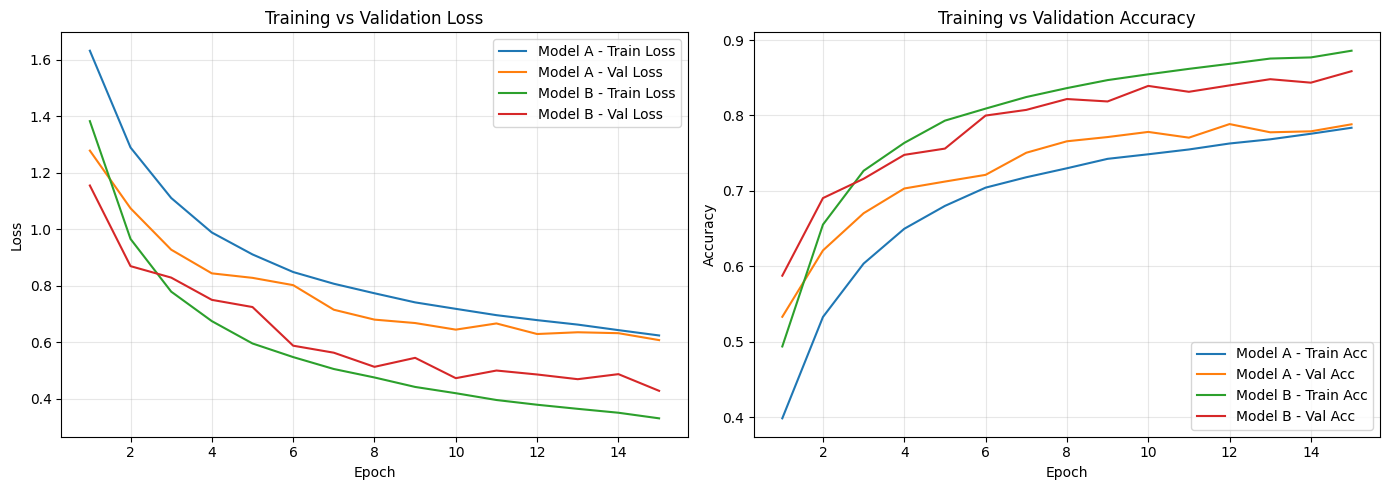

Grafik disimpan di: ./outputs/training_curves.png


In [9]:
plot_curves(history_a, history_b, os.path.join(OUTPUT_DIR, "training_curves.png"))

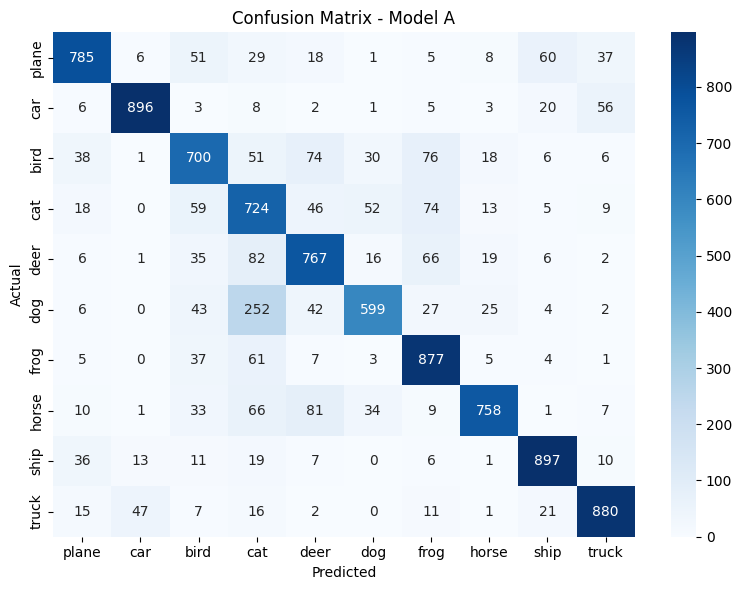

Confusion matrix disimpan di: ./outputs/confusion_matrix_model_a.png


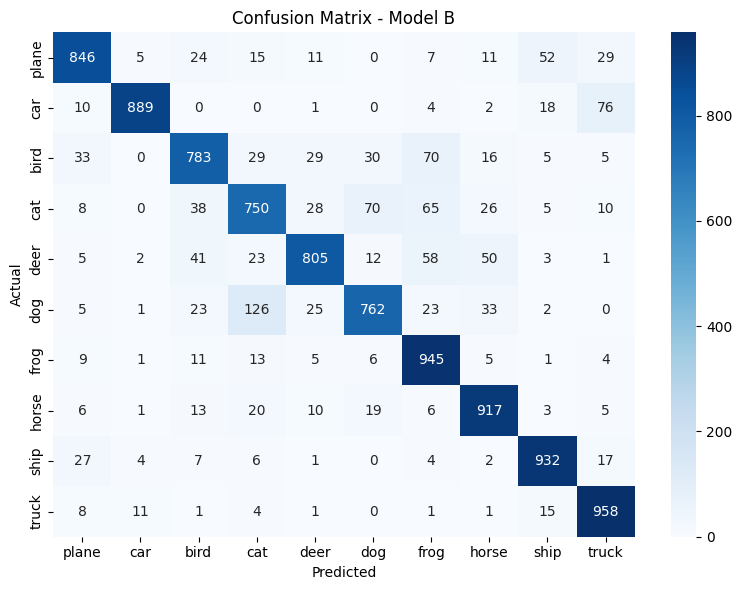

Confusion matrix disimpan di: ./outputs/confusion_matrix_model_b.png


array([[846,   5,  24,  15,  11,   0,   7,  11,  52,  29],
       [ 10, 889,   0,   0,   1,   0,   4,   2,  18,  76],
       [ 33,   0, 783,  29,  29,  30,  70,  16,   5,   5],
       [  8,   0,  38, 750,  28,  70,  65,  26,   5,  10],
       [  5,   2,  41,  23, 805,  12,  58,  50,   3,   1],
       [  5,   1,  23, 126,  25, 762,  23,  33,   2,   0],
       [  9,   1,  11,  13,   5,   6, 945,   5,   1,   4],
       [  6,   1,  13,  20,  10,  19,   6, 917,   3,   5],
       [ 27,   4,   7,   6,   1,   0,   4,   2, 932,  17],
       [  8,  11,   1,   4,   1,   0,   1,   1,  15, 958]])

In [10]:
y_true_a, y_pred_a = get_predictions(model_a, testloader, DEVICE)
y_true_b, y_pred_b = get_predictions(model_b, testloader, DEVICE)

plot_confusion_matrix(y_true_a, y_pred_a, CIFAR10_CLASSES, "Model A",
                       os.path.join(OUTPUT_DIR, "confusion_matrix_model_a.png"))
plot_confusion_matrix(y_true_b, y_pred_b, CIFAR10_CLASSES, "Model B",
                       os.path.join(OUTPUT_DIR, "confusion_matrix_model_b.png"))

## (Opsional) Simpan Bobot Model

In [ ]:
torch.save(model_a.state_dict(), os.path.join(OUTPUT_DIR, "model_a_weights.pth"))
torch.save(model_b.state_dict(), os.path.join(OUTPUT_DIR, "model_b_weights.pth"))
print("Model tersimpan di folder outputs/")

## (Opsional) Download semua hasil sebagai .zip
Jalankan cell di bawah kalau mau download semua grafik & weights sekaligus.

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("hasil_tugas_dl", "zip", OUTPUT_DIR)
files.download("hasil_tugas_dl.zip")